In [1]:
import pandas as pd

df = pd.read_csv('/Users/hanna/Downloads/early_wakeup_health_dataset.csv')
print(df.shape)
df.head()

(10000, 64)


,Person_ID,Age,Gender,Height_cm,Weight_kg,BMI,Country,Occupation,Marital_Status,Wake_Up_Time,...,Obesity_Risk,Hypertension_Risk,Diabetes_Risk,Cardiovascular_Risk,Sleep_Disorder_Risk,Health_Score,Fitness_Level,Healthy_Aging_Score,Wellness_Category,Early_Waker
0,P00001,76,Female,158.8,62.1,24.63,Italy,Entrepreneur,Widowed,08:59,...,Low,High,Medium,Medium,Low,87.3,Excellent,81.8,Excellent,No
1,P00002,49,Female,160.9,68.5,26.45,USA,Freelancer,Single,06:35,...,Medium,Medium,Medium,Low,Medium,72.0,Good,75.2,Good,No
2,P00003,51,Female,151.9,54.8,23.77,Mexico,Nurse,Single,07:31,...,Low,Medium,Medium,Low,Low,75.2,Good,77.1,Good,No
3,P00004,48,Male,167.6,81.3,28.93,Australia,Laborer,Single,08:36,...,Medium,Medium,Low,Low,Medium,82.7,Excellent,87.1,Excellent,No
4,P00005,68,Female,171.9,75.4,25.51,USA,Software Engineer,Married,07:07,...,Medium,High,Medium,Medium,Low,62.7,Average,58.1,Average,No


In [2]:
df[['Early_Waker', 'Productivity_Score', 'Sleep_Duration_Hours', 
    'Stress_Level', 'Mood_Score', 'Focus_Concentration_Score']].describe()

,Productivity_Score,Sleep_Duration_Hours,Stress_Level,Mood_Score,Focus_Concentration_Score
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000
mean,7.06533,7.229332,4.523980,6.779650,6.85799
std,1.14750,1.118486,1.973322,1.255232,0.95254
min,2.80000,4.000000,1.000000,2.000000,3.50000
25%,6.30000,6.470000,3.100000,5.900000,6.20000
50%,7.00000,7.230000,4.500000,6.800000,6.90000
75%,7.90000,7.980000,5.900000,7.700000,7.50000
max,10.00000,10.000000,10.000000,10.000000,10.00000


In [5]:
df.groupby('Early_Waker')[['Productivity_Score', 'Mood_Score', 
                            'Stress_Level', 'Focus_Concentration_Score']].mean().round(2)

,Productivity_Score,Mood_Score,Stress_Level,Focus_Concentration_Score
Early_Waker,,,,
No,6.64,6.70,4.57,6.81
Yes,7.66,6.89,4.45,6.93


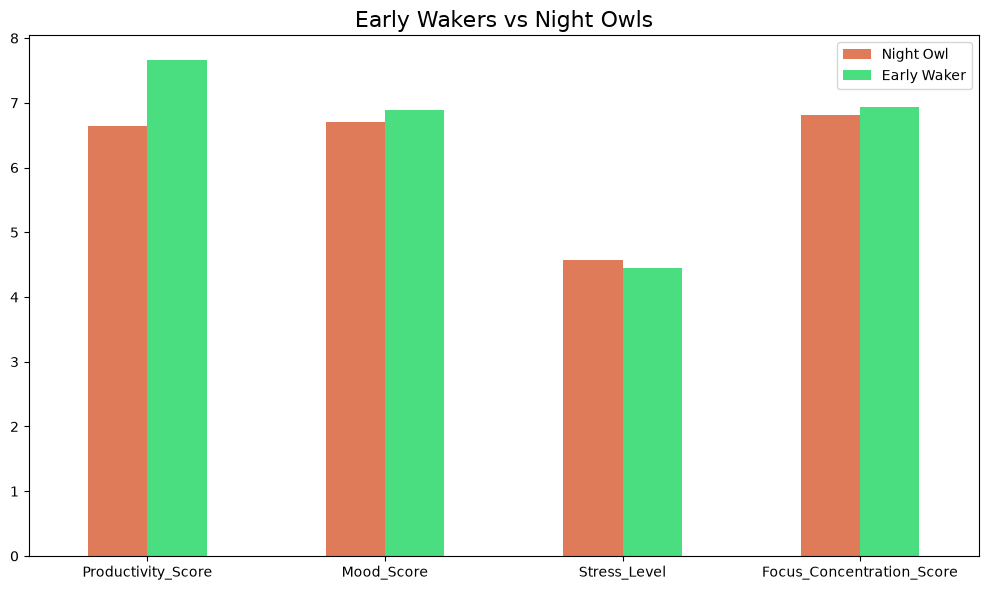

In [7]:
import matplotlib.pyplot as plt

comparison = df.groupby('Early_Waker')[['Productivity_Score', 'Mood_Score', 
                                        'Stress_Level', 'Focus_Concentration_Score']].mean().round(2)

comparison.T.plot(kind='bar', figsize=(10, 6), color=['#e07b5a', '#4ade80'])
plt.title('Early Wakers vs Night Owls', fontsize=16)
plt.xticks(rotation=0)
plt.legend(['Night Owl', 'Early Waker'])
plt.tight_layout()
plt.show()

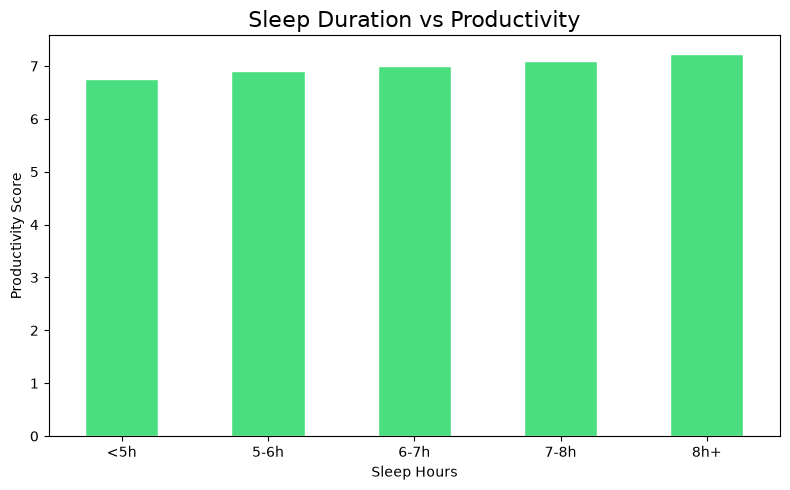

In [10]:
df['Sleep_Group'] = pd.cut(df['Sleep_Duration_Hours'], 
                            bins=[3, 5, 6, 7, 8, 10], 
                            labels=['<5h', '5-6h', '6-7h', '7-8h', '8h+'])

df.groupby('Sleep_Group')['Productivity_Score'].mean().round(2).plot(
    kind='bar', figsize=(8, 5), color='#4ade80', edgecolor='white')
plt.title('Sleep Duration vs Productivity', fontsize=16)
plt.xlabel('Sleep Hours')
plt.ylabel('Productivity Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

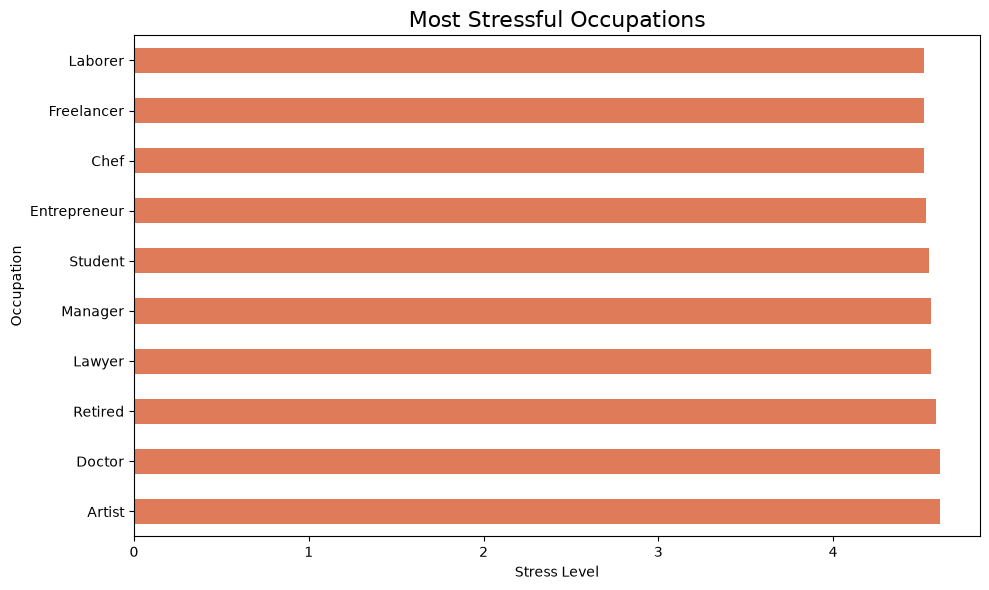

In [11]:
top_jobs = df.groupby('Occupation')['Stress_Level'].mean().round(2).sort_values(ascending=False).head(10)

top_jobs.plot(kind='barh', figsize=(10, 6), color='#e07b5a')
plt.title('Most Stressful Occupations', fontsize=16)
plt.xlabel('Stress Level')
plt.tight_layout()
plt.show()

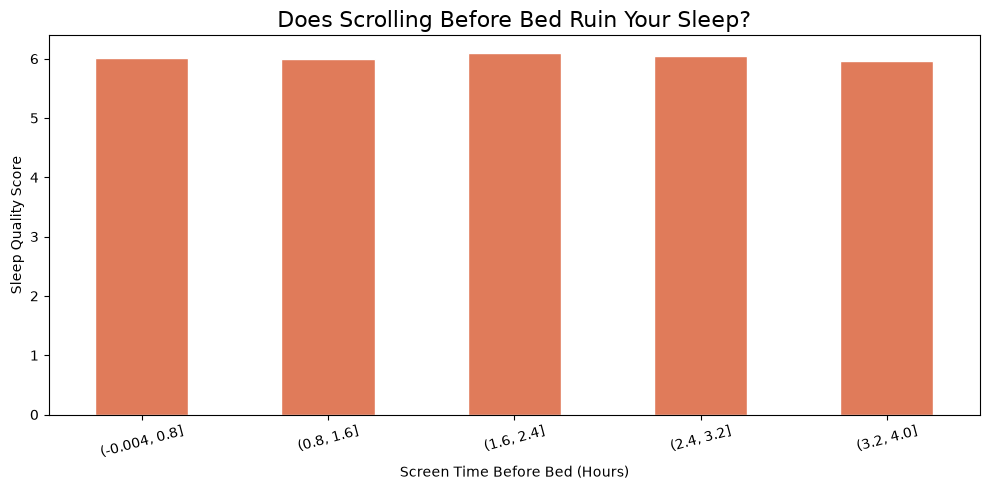

In [12]:
df.groupby(pd.cut(df['Screen_Time_Before_Bed_Hours'], bins=5))['Sleep_Quality_Score'].mean().round(2).plot(
    kind='bar', figsize=(10, 5), color='#e07b5a', edgecolor='white')
plt.title('Does Scrolling Before Bed Ruin Your Sleep?', fontsize=16)
plt.xlabel('Screen Time Before Bed (Hours)')
plt.ylabel('Sleep Quality Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()